In [2]:
import datetime
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:

dt = pd.read_csv("Customer-Churn-Records.csv")
print(type(dt))
dt.head()

<class 'pandas.DataFrame'>


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
dt.shape

(10000, 18)

In [5]:
dt.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [6]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [7]:
dt.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [8]:
dt = dt.drop(["RowNumber","CustomerId","Surname"], axis = 1)

In [9]:
print(dt.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']


In [10]:
dt.isna().sum()

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [11]:
dt.dtypes

CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object

In [12]:
dt = dt.rename(columns={
    'Satisfaction Score' : 'SatisfactionScore',
    'Card Type' : 'CardType',
    'Point Earned' : 'PointEarned'
})

In [13]:
dt

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [14]:
#What is the overall churn rate? 

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


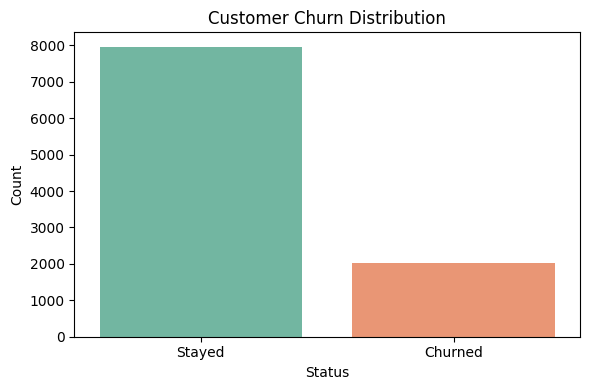

In [15]:
churn_rate = dt['Exited'].value_counts(normalize=True) * 100
print(churn_rate)

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(data=dt, x='Exited', hue='Exited', palette='Set2', legend=False)
plt.title('Customer Churn Distribution')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show() 

# 20.38% of customers churned — 1 in 5 customers left the bank.
# This is a significant churn rate for a retail bank.
# Retaining these customers should be a top business priority.

In [16]:
#Which Geography has the highest churn? 

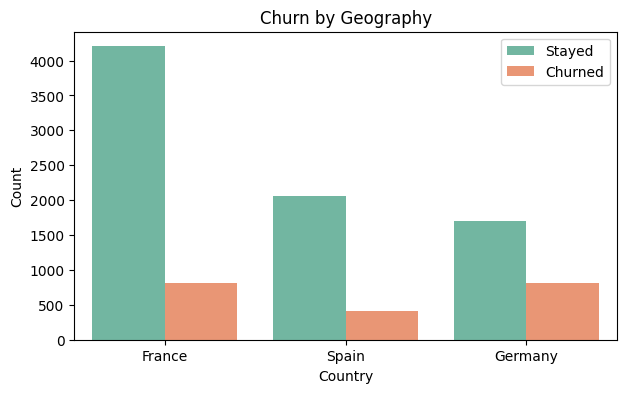

Geography
France     16.174711
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


In [17]:
plt.figure(figsize = (7,4))
sns.countplot(data=dt, x='Geography', hue='Exited', palette='Set2')
plt.title('Churn by Geography')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.show()

#churning rate by country
print(dt.groupby('Geography')['Exited'].mean()* 100)

# Germany has a 32.4% churn rate — double that of France (16.2%) and Spain (16.7%).
# Despite having fewer customers, Germany loses 1 in 3 customers.
# The bank has a serious retention problem specifically in Germany.

In [18]:
#Which age segment should retention marketing focus more on?

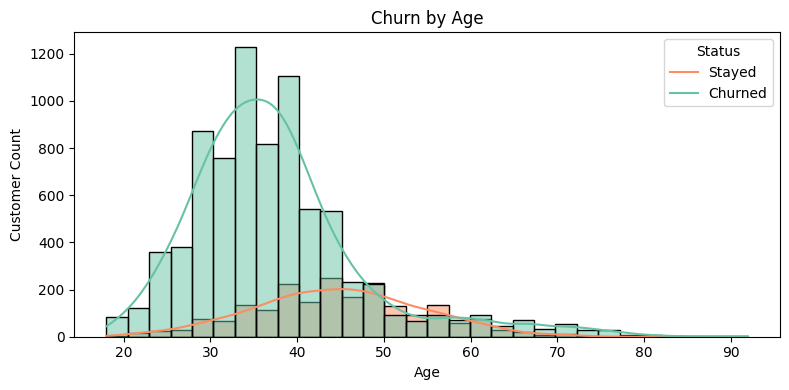

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(data=dt, x='Age', hue='Exited', bins=30, kde = True, palette='Set2')
plt.title('Churn by Age')
plt.xlabel('Age')
plt.ylabel('Customer Count')
plt.tight_layout()

plt.legend(title='Status', labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

In [20]:
print(dt.groupby('Exited')['Age'].mean())

Exited
0    37.408063
1    44.835623
Name: Age, dtype: float64


# Customers who churned are on average 44.8 years old.
# Customers who stayed are on average 37.4 years old.
# A 7-year age gap. Middle-aged customers leave more.
# Retention campaigns should target customers aged 40-55.

In [21]:
# Do inactive members churn more? 

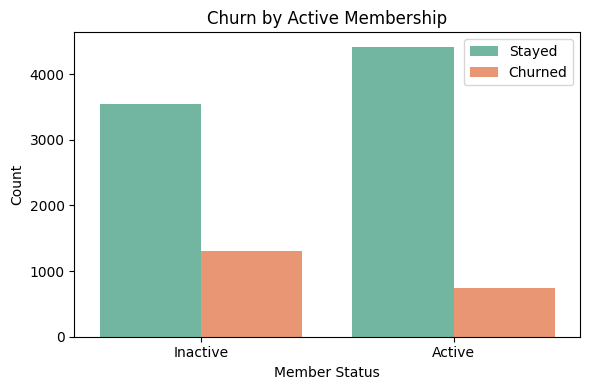

IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64


In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data=dt, x ='IsActiveMember', hue='Exited', palette = 'Set2')
plt.title('Churn by Active Membership')
plt.xticks([0,1], ['Inactive', 'Active'])
plt.xlabel('Member Status')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print(dt.groupby('IsActiveMember')['Exited'].mean() * 100)

In [23]:
# Inactive members churn at 26.9% vs 14.3% for active members.
# Engagement is a strong predictor of churn.
# The bank should push inactive customers to use their accounts more.
# Simple triggers: app notifications, rewards, personalized offers.

In [24]:
# Does number of products affect churn

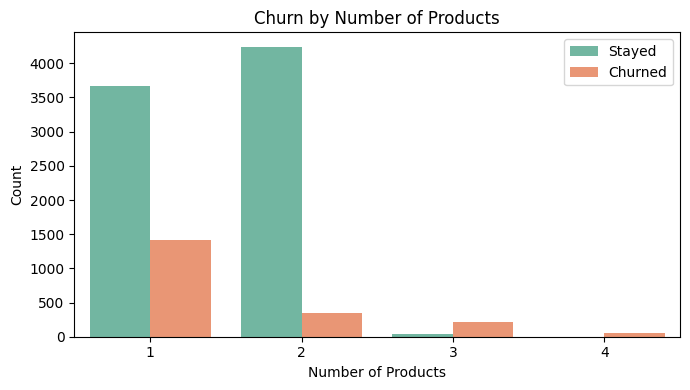

NumOfProducts
1     27.714398
2      7.603486
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [25]:
plt.figure(figsize=(7,4)) 
sns.countplot(data=dt, x = 'NumOfProducts', hue='Exited', palette='Set2')
plt.title('Churn by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print(dt.groupby('NumOfProducts')['Exited'].mean()* 100)

In [26]:
# Customers with 2 products have the lowest churn rate at 7.6%.
# Customers with 3-4 products churn at extreme rates (83-100%).
# Selling too many products to one customer backfires badly.
# The bank's sweet spot is 2 products per customer.

In [27]:
## Does complaint history drive churn?

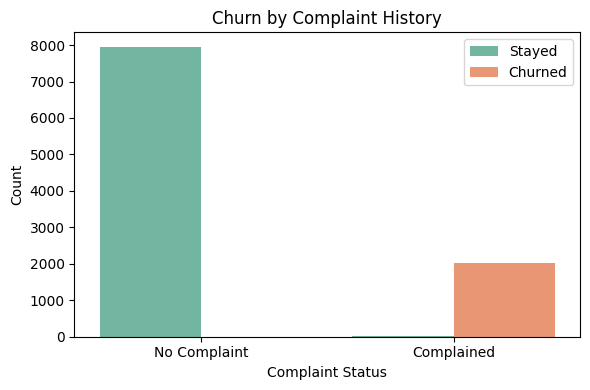

Complain
0     0.050277
1    99.510763
Name: Exited, dtype: float64


In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=dt, x='Complain', hue='Exited', palette='Set2')
plt.title('Churn by Complaint History')
plt.xticks([0,1], ['No Complaint', 'Complained'])
plt.xlabel('Complaint Status')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print(dt.groupby('Complain')['Exited'].mean() * 100)

# 99.5% of customers who complained ended up churning.
# Complaints are the single strongest predictor of churn in this dataset.
# The bank's complaint resolution process is completely broken.
# Every complaint should be treated as a red alert.

A 99.5% correlation is too clean to be causal — this smells like data leakage, not insight.

In [29]:
#Which card type has the highest churn ?

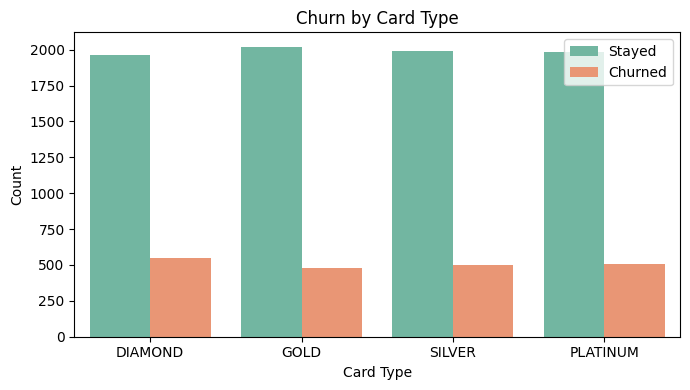

CardType
DIAMOND     21.779019
GOLD        19.264588
PLATINUM    20.360721
SILVER      20.112179
Name: Exited, dtype: float64


In [30]:
plt.figure(figsize=(7,4))
sns.countplot(data=dt, x='CardType', hue='Exited', palette='Set2')
plt.title('Churn by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Count')
plt.legend(['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print(dt.groupby('CardType')['Exited'].mean() * 100)

# Churn rates are almost identical across all card types (19-22%).
# Card type is not a predictor of churn.
# Premium card holders (Diamond, Platinum) leave just as much as basic ones.
# The bank's card loyalty program is not working.

In [31]:
#Does credit score affect churn?

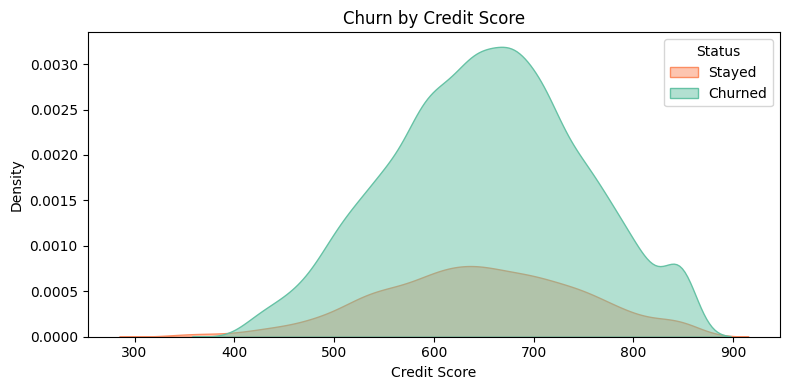

Exited
0    651.837855
1    645.414622
Name: CreditScore, dtype: float64


In [32]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=dt, x='CreditScore', hue='Exited', fill=True, palette='Set2', alpha=0.5)
plt.title('Churn by Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend(title='Status', labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

print(dt.groupby('Exited')['CreditScore'].mean())

# Credit score has no meaningful impact on churn.
# Both groups score within 6 points of each other.
# The bank cannot use credit score to identify at-risk customers.

<Axes: >

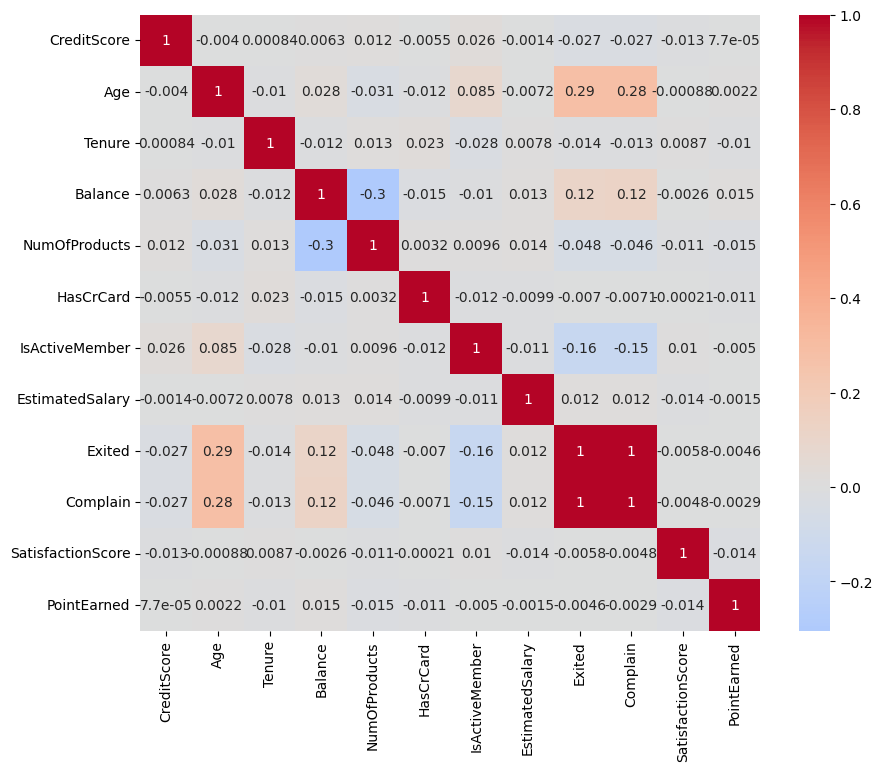

In [33]:
#Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(dt.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)

In [34]:
#business cost

lost_balance = dt[dt['Exited']==1]['Balance'].sum()
print(f"Total balance lost to churn: ${lost_balance:,.0f}")

Total balance lost to churn: $185,681,112


## Key Findings & Business Recommendations
1. Germany churn (32.4%) — investigate local competitor pricing or service gaps 

Recommendation: analyze pricing in local competitors and gaps in service 
quality in Germany

2. Complaint = near-certain churn.
Recommendation : build an early-warning system, not just "resolve faster"

3. 3-4 product customers churn 83-100%.
Recommendation: audit cross-sell practices, sales team may be over-selling

4. Inactive members churn at 26.9% vs 14.3% active.
Recommendation: automated re-engagement triggers for 30+ days inactive.

5. Churners average 44.8 vs 37.4 years old.
Recommendation: target retention campaigns at 40-55 age bracket.